# Retail Sales Forecasting - Data Science Analysis

This notebook performs exploratory data analysis (EDA) and time series forecasting on the Superstore Sales dataset using LSTM and GRU neural networks.

**Goal:** Predict future sales values based on historical patterns, comparing different temporal granularities (weekly aggregation vs. 7-day rolling averages) and recurrent architectures (LSTM vs. GRU).

**Sections:**
1. Data Loading & EDA
2. Feature Extraction (cyclical encoding)
3. Data Scaling (StandardScaler)
4. Train/Validation/Test Split
5. LSTM Model
6. GRU Model
7. Results Comparison & Visualization

## 1. Data Loading & Exploratory Data Analysis

**What:** We load the raw transactional sales data (split into 4 chunks simulating a data warehouse), then aggregate it into daily, weekly, and 7-day rolling average time series.

**Why:** Raw transactional data contains individual order lines — not suitable for time series forecasting. Aggregating to regular intervals (daily/weekly) creates a proper time series. We also compute a 7-day rolling average to smooth out daily noise while retaining daily-level granularity, giving us two candidate representations to model.

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.callbacks import EarlyStopping

In [24]:
import glob

# Dynamically load all available chunks from the split folder
chunk_files = sorted(glob.glob('../data/split/sales_chunk_*.csv'))

if not chunk_files:
    raise FileNotFoundError("No sales_chunk_*.csv files found in ../data/split/")

chunks = [pd.read_csv(f) for f in chunk_files]
df = pd.concat(chunks, ignore_index=True)

print(f"Loaded {len(chunk_files)} chunk(s): {[os.path.basename(f) for f in chunk_files]}")
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 4 chunk(s): ['sales_chunk_1.csv', 'sales_chunk_2.csv', 'sales_chunk_3.csv', 'sales_chunk_4.csv']
Total rows: 9994
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [25]:
# Parse dates and create daily aggregated sales
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
daily_sales = df.groupby('Order Date').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum'),
    OrderCount=('Order ID', 'nunique')
).reset_index()
daily_sales.columns = ['Date', 'Sales', 'Profit', 'Quantity', 'OrderCount']
daily_sales.set_index('Date', inplace=True)
daily_sales = daily_sales.asfreq('D', fill_value=0)

# Create weekly aggregation
weekly_sales = daily_sales.resample('W').sum()

# Create 7-day rolling average (on daily data)
rolling_sales = daily_sales.copy()
rolling_sales['Sales'] = daily_sales['Sales'].rolling(window=7, min_periods=1).mean()
rolling_sales['Profit'] = daily_sales['Profit'].rolling(window=7, min_periods=1).mean()
rolling_sales['Quantity'] = daily_sales['Quantity'].rolling(window=7, min_periods=1).mean()
rolling_sales['OrderCount'] = daily_sales['OrderCount'].rolling(window=7, min_periods=1).mean()

print(f"Daily rows: {len(daily_sales)}")
print(f"Weekly rows: {len(weekly_sales)}")
print(f"Rolling avg rows: {len(rolling_sales)}")
print(f"Date range: {daily_sales.index.min()} to {daily_sales.index.max()}")

Daily rows: 1458
Weekly rows: 209
Rolling avg rows: 1458
Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00


### EDA: Sales Distribution & Trends

**What:** We visualize the sales time series at different granularities (daily, weekly, rolling average) and examine statistical properties like distributions and day-of-week patterns.

**Why:** Understanding the data's characteristics — seasonality, trends, variance, and cyclical patterns — informs our modeling choices. For example, the high variance in daily data motivates using smoothed representations, and day-of-week patterns justify including cyclical time features.

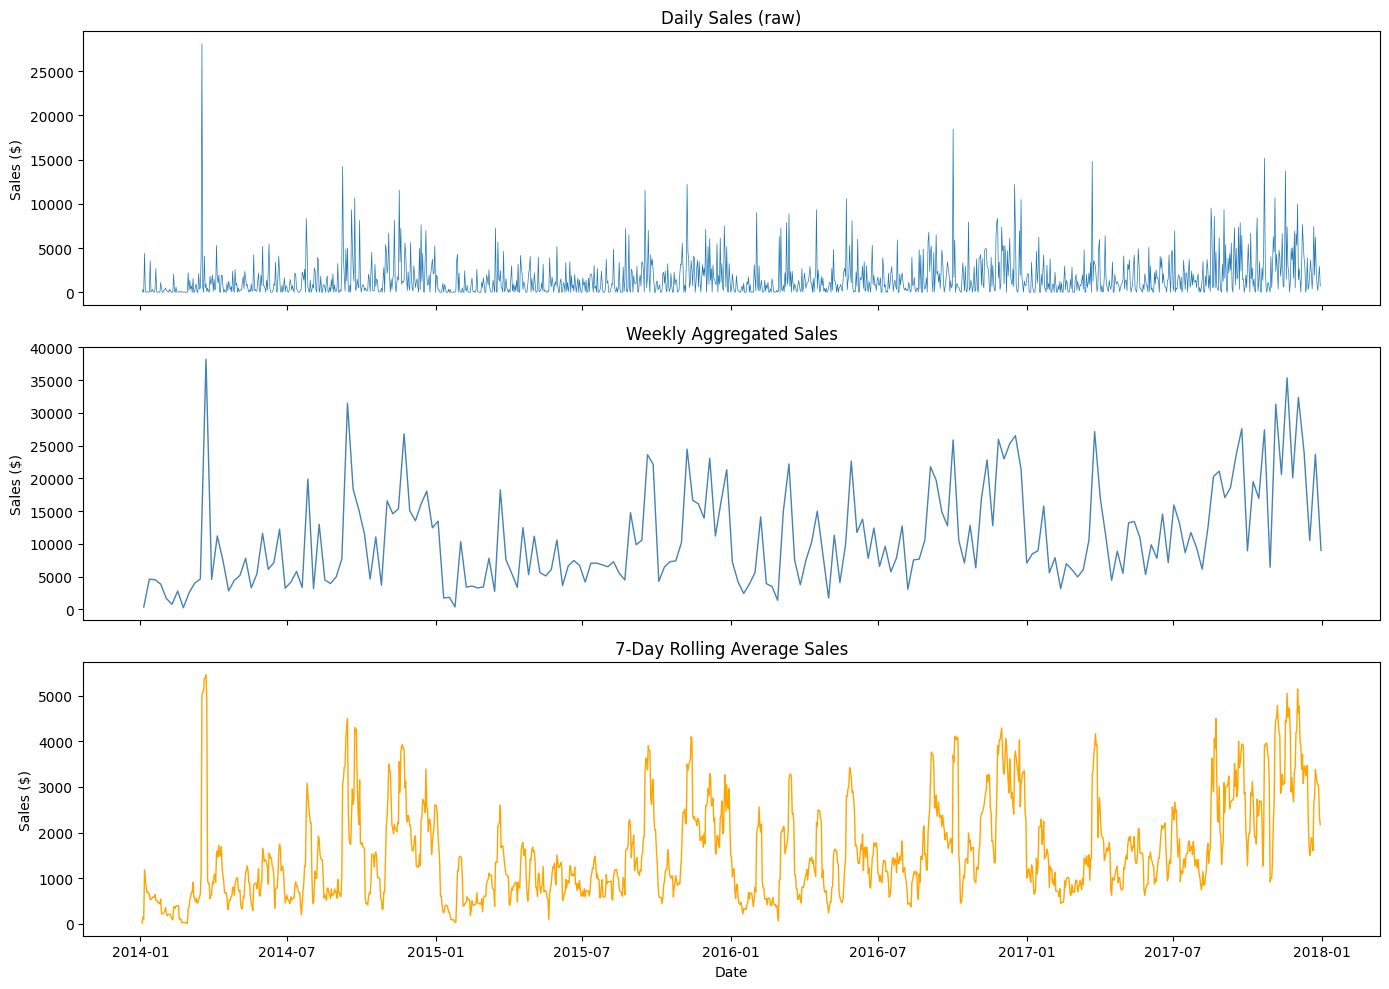

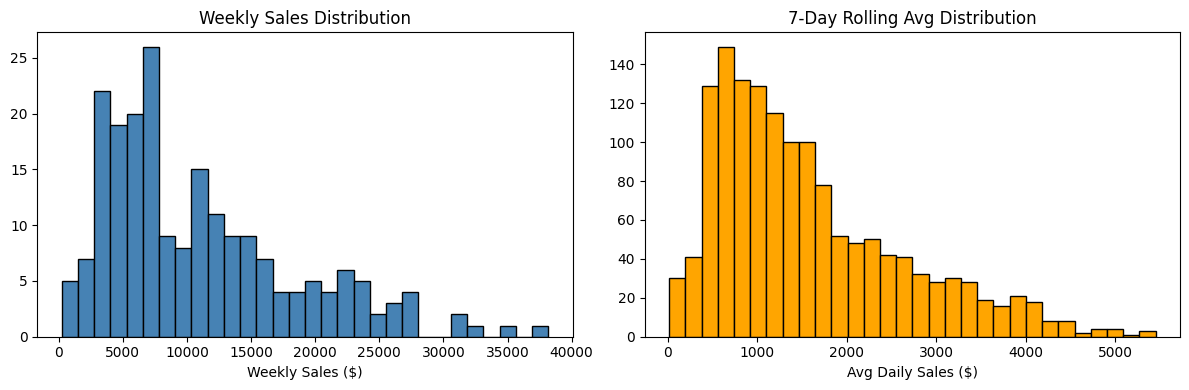

In [26]:
# Compare daily, weekly, and rolling average
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(daily_sales.index, daily_sales['Sales'], linewidth=0.5)
axes[0].set_title('Daily Sales (raw)')
axes[0].set_ylabel('Sales ($)')

axes[1].plot(weekly_sales.index, weekly_sales['Sales'], linewidth=1, color='steelblue')
axes[1].set_title('Weekly Aggregated Sales')
axes[1].set_ylabel('Sales ($)')

axes[2].plot(rolling_sales.index, rolling_sales['Sales'], linewidth=1, color='orange')
axes[2].set_title('7-Day Rolling Average Sales')
axes[2].set_ylabel('Sales ($)')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(weekly_sales['Sales'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Weekly Sales Distribution')
axes[0].set_xlabel('Weekly Sales ($)')

axes[1].hist(rolling_sales['Sales'][rolling_sales['Sales'] > 0], bins=30, color='orange', edgecolor='black')
axes[1].set_title('7-Day Rolling Avg Distribution')
axes[1].set_xlabel('Avg Daily Sales ($)')

plt.tight_layout()
plt.show()

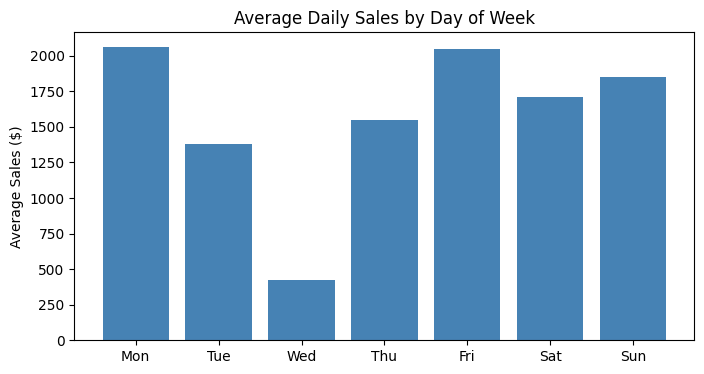

In [27]:
# Day-of-week pattern
dow_sales = daily_sales.copy()
dow_sales['DayOfWeek'] = dow_sales.index.dayofweek
dow_avg = dow_sales.groupby('DayOfWeek')['Sales'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(8, 4))
plt.bar(day_names, dow_avg.values, color='steelblue')
plt.title('Average Daily Sales by Day of Week')
plt.ylabel('Average Sales ($)')
plt.show()

In [28]:
# Basic statistics
print("=== Daily Sales Statistics ===")
print(daily_sales.describe())
print(f"\nTotal revenue: ${daily_sales['Sales'].sum():,.2f}")
print(f"Total profit: ${daily_sales['Profit'].sum():,.2f}")
print(f"Profit margin: {daily_sales['Profit'].sum() / daily_sales['Sales'].sum() * 100:.1f}%")

=== Daily Sales Statistics ===
              Sales       Profit     Quantity   OrderCount
count   1458.000000  1458.000000  1458.000000  1458.000000
mean    1575.583580   196.431428    25.975995     3.435528
std     2225.547339   652.857001    25.436615     2.996273
min        0.000000 -6247.396900     0.000000     0.000000
25%      121.927500     0.000000     6.000000     1.000000
50%      823.476000    57.168000    19.000000     3.000000
75%     2083.569500   262.860450    39.000000     5.000000
max    28106.716000  8738.797100   152.000000    19.000000

Total revenue: $2,297,200.86
Total profit: $286,397.02
Profit margin: 12.5%


## 2. Feature Extraction

**What:** We create cyclical time features using sine/cosine transformations. For weekly data, we encode week-of-year and month. For rolling average data, we encode day-of-week and day-of-year.

**Why:** Time features like "day of week" or "week of year" are inherently cyclical (e.g., day 7 is adjacent to day 1). Simple integer encoding would imply that Monday and Sunday are maximally distant, which is incorrect. Sine/cosine encoding preserves the circular relationship, allowing the model to properly learn periodic sales patterns (e.g., end-of-year spikes, weekday vs. weekend differences).

In [29]:
# Feature extraction for WEEKLY data
weekly_feat = weekly_sales.copy()
weekly_feat['WeekOfYear'] = weekly_feat.index.isocalendar().week.astype(int)
weekly_feat['Month'] = weekly_feat.index.month

# Cyclical encoding
weekly_feat['WoY_X'] = np.sin(2 * np.pi * weekly_feat['WeekOfYear'] / 52)
weekly_feat['WoY_Y'] = np.cos(2 * np.pi * weekly_feat['WeekOfYear'] / 52)
weekly_feat['Month_X'] = np.sin(2 * np.pi * weekly_feat['Month'] / 12)
weekly_feat['Month_Y'] = np.cos(2 * np.pi * weekly_feat['Month'] / 12)
weekly_feat.drop(['WeekOfYear', 'Month'], axis=1, inplace=True)

# Feature extraction for ROLLING AVERAGE data
rolling_feat = rolling_sales.copy()
rolling_feat['DayOfWeek'] = rolling_feat.index.dayofweek
rolling_feat['DayOfYear'] = rolling_feat.index.dayofyear

rolling_feat['DoW_X'] = np.sin(2 * np.pi * rolling_feat['DayOfWeek'] / 7)
rolling_feat['DoW_Y'] = np.cos(2 * np.pi * rolling_feat['DayOfWeek'] / 7)
rolling_feat['DoY_X'] = np.sin(2 * np.pi * rolling_feat['DayOfYear'] / 365)
rolling_feat['DoY_Y'] = np.cos(2 * np.pi * rolling_feat['DayOfYear'] / 365)
rolling_feat.drop(['DayOfWeek', 'DayOfYear'], axis=1, inplace=True)

print("Weekly features:", weekly_feat.columns.tolist())
print(f"Weekly shape: {weekly_feat.shape}")
print("\nRolling features:", rolling_feat.columns.tolist())
print(f"Rolling shape: {rolling_feat.shape}")

Weekly features: ['Sales', 'Profit', 'Quantity', 'OrderCount', 'WoY_X', 'WoY_Y', 'Month_X', 'Month_Y']
Weekly shape: (209, 8)

Rolling features: ['Sales', 'Profit', 'Quantity', 'OrderCount', 'DoW_X', 'DoW_Y', 'DoY_X', 'DoY_Y']
Rolling shape: (1458, 8)


## 3. Data Scaling & 4. Train/Validation/Test Split

**What:** We split the data chronologically (2014–2015 for training, 2016 for validation, 2017 for testing), then apply StandardScaler to normalize all features to zero mean and unit variance. The scaler is fitted only on training data to prevent data leakage.

**Why:** Neural networks (LSTM/GRU) converge faster and more reliably when inputs are normalized. A time-based split (rather than random) is essential for time series to avoid "future information leakage" — the model must never see future data during training. Separate scalers for input features and the target variable allow us to properly inverse-transform predictions back to original dollar values.

In [30]:
# Time-based split for WEEKLY data
train_w = weekly_feat[weekly_feat.index < '2016'].copy()
valid_w = weekly_feat[(weekly_feat.index >= '2016') & (weekly_feat.index < '2017')].copy()
test_w = weekly_feat[weekly_feat.index >= '2017'].copy()

# Time-based split for ROLLING data
train_r = rolling_feat[rolling_feat.index < '2016'].copy()
valid_r = rolling_feat[(rolling_feat.index >= '2016') & (rolling_feat.index < '2017')].copy()
test_r = rolling_feat[rolling_feat.index >= '2017'].copy()

print("=== Weekly Split ===")
print(f"Train: {len(train_w)} weeks, Valid: {len(valid_w)} weeks, Test: {len(test_w)} weeks")
print(f"\n=== Rolling Average Split ===")
print(f"Train: {len(train_r)} days, Valid: {len(valid_r)} days, Test: {len(test_r)} days")

=== Weekly Split ===
Train: 104 weeks, Valid: 52 weeks, Test: 53 weeks

=== Rolling Average Split ===
Train: 728 days, Valid: 366 days, Test: 364 days


In [31]:
# Scale WEEKLY data
scaler_w_in = StandardScaler()
scaler_w_out = StandardScaler()

scaled_train_w = scaler_w_in.fit_transform(train_w)
target_train_w = scaler_w_out.fit_transform(train_w[['Sales']])
scaled_valid_w = scaler_w_in.transform(valid_w)
target_valid_w = scaler_w_out.transform(valid_w[['Sales']])
scaled_test_w = scaler_w_in.transform(test_w)
target_test_w = scaler_w_out.transform(test_w[['Sales']])

# Scale ROLLING data
scaler_r_in = StandardScaler()
scaler_r_out = StandardScaler()

scaled_train_r = scaler_r_in.fit_transform(train_r)
target_train_r = scaler_r_out.fit_transform(train_r[['Sales']])
scaled_valid_r = scaler_r_in.transform(valid_r)
target_valid_r = scaler_r_out.transform(valid_r[['Sales']])
scaled_test_r = scaler_r_in.transform(test_r)
target_test_r = scaler_r_out.transform(test_r[['Sales']])

print(f"Weekly scaled train: {scaled_train_w.shape}")
print(f"Rolling scaled train: {scaled_train_r.shape}")

Weekly scaled train: (104, 8)
Rolling scaled train: (728, 8)


### Sequence Creation

**What:** We transform the flat time series into overlapping sequences of fixed length (`lookback` timesteps) as input, with the next value as the target. Weekly data uses a lookback of 8 weeks; rolling average data uses 14 days.

**Why:** Recurrent networks (LSTM/GRU) expect 3D input of shape `(samples, timesteps, features)`. Each sample is a sliding window of historical observations that the model uses to predict the next value. The lookback length determines how much history the model can "see" — 8 weeks captures ~2 months of weekly patterns, while 14 days captures 2 weeks of daily dynamics.

In [32]:
def process_Xy(raw_X: np.array, raw_y: np.array, lookback: int) -> tuple:
    """Create sequences of length `lookback` for time series modeling."""
    X = np.empty(shape=(raw_X.shape[0] - lookback, lookback, raw_X.shape[1]), dtype=np.float32)
    y = np.empty(shape=(raw_y.shape[0] - lookback), dtype=np.float32)

    target_index = 0
    for i in range(lookback, raw_X.shape[0]):
        X[target_index] = raw_X[i - lookback : i]
        y[target_index] = raw_y[i].item()
        target_index += 1

    return X.copy(), y.copy()

# Weekly: lookback = 8 weeks (~2 months of history)
lookback_w = 8
train_Xw, train_yw = process_Xy(scaled_train_w, target_train_w, lookback=lookback_w)
valid_Xw, valid_yw = process_Xy(scaled_valid_w, target_valid_w, lookback=lookback_w)
test_Xw, test_yw = process_Xy(scaled_test_w, target_test_w, lookback=lookback_w)

# Rolling: lookback = 14 days (2 weeks of history)
lookback_r = 14
train_Xr, train_yr = process_Xy(scaled_train_r, target_train_r, lookback=lookback_r)
valid_Xr, valid_yr = process_Xy(scaled_valid_r, target_valid_r, lookback=lookback_r)
test_Xr, test_yr = process_Xy(scaled_test_r, target_test_r, lookback=lookback_r)

print("=== Weekly Sequences ===")
print(f"Train X: {train_Xw.shape}, Train y: {train_yw.shape}")
print(f"Valid X: {valid_Xw.shape}, Valid y: {valid_yw.shape}")
print(f"Test  X: {test_Xw.shape}, Test  y: {test_yw.shape}")
print(f"\n=== Rolling Sequences ===")
print(f"Train X: {train_Xr.shape}, Train y: {train_yr.shape}")
print(f"Valid X: {valid_Xr.shape}, Valid y: {valid_yr.shape}")
print(f"Test  X: {test_Xr.shape}, Test  y: {test_yr.shape}")

=== Weekly Sequences ===
Train X: (96, 8, 8), Train y: (96,)
Valid X: (44, 8, 8), Valid y: (44,)
Test  X: (45, 8, 8), Test  y: (45,)

=== Rolling Sequences ===
Train X: (714, 14, 8), Train y: (714,)
Valid X: (352, 14, 8), Valid y: (352,)
Test  X: (350, 14, 8), Test  y: (350,)


## 5. LSTM Model

**What:** We build and train an LSTM (Long Short-Term Memory) network with 16 units followed by a Dense output layer. The model is trained on both weekly and rolling average data separately, using EarlyStopping to prevent overfitting.

**Why:** LSTM is specifically designed for sequential data — its gating mechanism (forget, input, output gates) allows it to learn long-term dependencies in time series. Training on two different data granularities lets us empirically determine which representation is more effective for this dataset. EarlyStopping monitors validation loss and restores the best weights, ensuring we don't overfit to the limited training data.

In [33]:
# LSTM on WEEKLY data
model_lstm_w = keras.Sequential([
    layers.LSTM(16, activation="relu", input_shape=train_Xw.shape[1:]),
    layers.Dense(1),
])
model_lstm_w.compile(loss='MeanSquaredError', optimizer='Adam')

callbacks_w = [EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]
history_lstm_w = model_lstm_w.fit(
    train_Xw, train_yw,
    validation_data=(valid_Xw, valid_yw),
    batch_size=8, epochs=100, callbacks=callbacks_w, shuffle=True, verbose=0
)

# LSTM on ROLLING data
model_lstm_r = keras.Sequential([
    layers.LSTM(16, activation="relu", input_shape=train_Xr.shape[1:]),
    layers.Dense(1),
])
model_lstm_r.compile(loss='MeanSquaredError', optimizer='Adam')

callbacks_r = [EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)]
history_lstm_r = model_lstm_r.fit(
    train_Xr, train_yr,
    validation_data=(valid_Xr, valid_yr),
    batch_size=16, epochs=100, callbacks=callbacks_r, shuffle=True, verbose=0
)

print(f"LSTM Weekly - Best val_loss: {min(history_lstm_w.history['val_loss']):.4f} (epoch {np.argmin(history_lstm_w.history['val_loss'])+1})")
print(f"LSTM Rolling - Best val_loss: {min(history_lstm_r.history['val_loss']):.4f} (epoch {np.argmin(history_lstm_r.history['val_loss'])+1})")

LSTM Weekly - Best val_loss: 0.8100 (epoch 6)
LSTM Rolling - Best val_loss: 0.1934 (epoch 15)


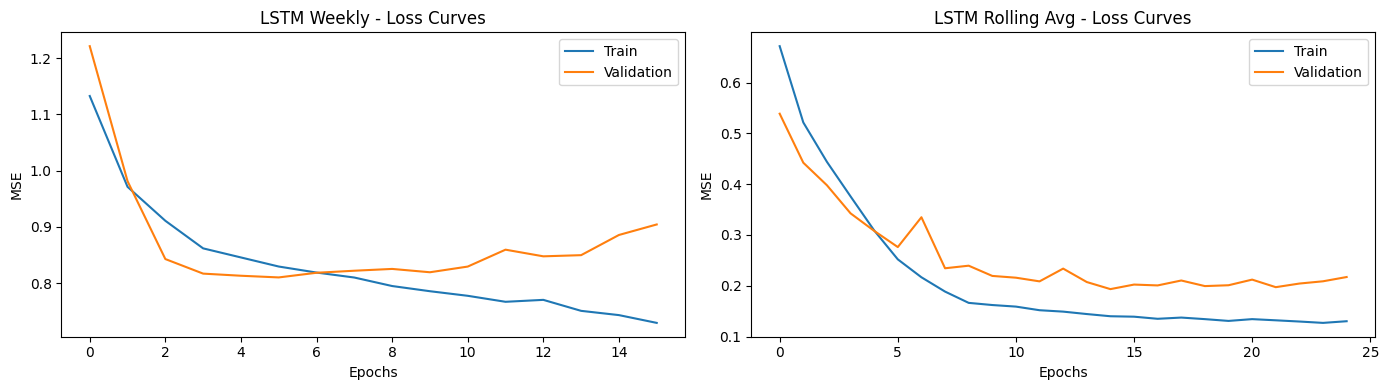

In [34]:
# LSTM Training Loss Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_lstm_w.history['loss'], label='Train')
axes[0].plot(history_lstm_w.history['val_loss'], label='Validation')
axes[0].set_title('LSTM Weekly - Loss Curves')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history_lstm_r.history['loss'], label='Train')
axes[1].plot(history_lstm_r.history['val_loss'], label='Validation')
axes[1].set_title('LSTM Rolling Avg - Loss Curves')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

11/11 [==============================] - 0s 1ms/step


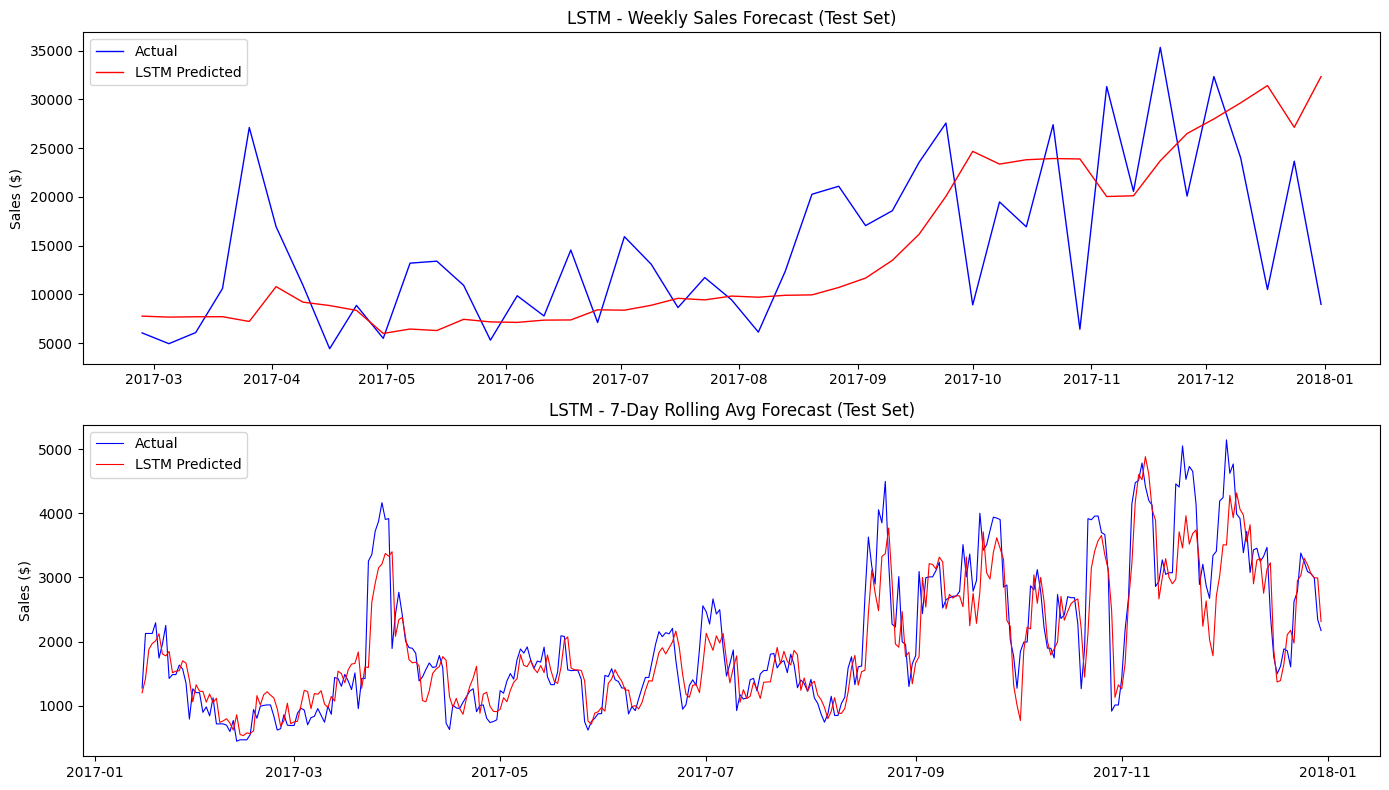

In [35]:
# LSTM Predictions Comparison
pred_lstm_w = model_lstm_w.predict(test_Xw)
pred_lstm_r = model_lstm_r.predict(test_Xr)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Weekly
test_dates_w = test_w.index[lookback_w:]
actual_w = test_w['Sales'].iloc[lookback_w:]
pred_w_inv = scaler_w_out.inverse_transform(pred_lstm_w).flatten()

axes[0].plot(test_dates_w, actual_w, label="Actual", color='blue', linewidth=1)
axes[0].plot(test_dates_w, pred_w_inv, label="LSTM Predicted", color='red', linewidth=1)
axes[0].set_title('LSTM - Weekly Sales Forecast (Test Set)')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()

# Rolling
test_dates_r = test_r.index[lookback_r:]
actual_r = test_r['Sales'].iloc[lookback_r:]
pred_r_inv = scaler_r_out.inverse_transform(pred_lstm_r).flatten()

axes[1].plot(test_dates_r, actual_r, label="Actual", color='blue', linewidth=0.8)
axes[1].plot(test_dates_r, pred_r_inv, label="LSTM Predicted", color='red', linewidth=0.8)
axes[1].set_title('LSTM - 7-Day Rolling Avg Forecast (Test Set)')
axes[1].set_ylabel('Sales ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. GRU Model

**What:** We build and train a GRU (Gated Recurrent Unit) network with the same architecture (16 units + Dense) on both weekly and rolling average data, using identical training settings as the LSTM.

**Why:** GRU is a simpler alternative to LSTM with fewer parameters (2 gates instead of 3), which can lead to faster training and sometimes better generalization on smaller datasets. By keeping all other factors constant (architecture size, data, training procedure), we isolate the effect of the recurrent cell type, enabling a fair comparison between LSTM and GRU for our forecasting task.

In [36]:
# GRU on WEEKLY data
model_gru_w = keras.Sequential([
    layers.GRU(16, activation="relu", input_shape=train_Xw.shape[1:]),
    layers.Dense(1),
])
model_gru_w.compile(loss='MeanSquaredError', optimizer='Adam')

history_gru_w = model_gru_w.fit(
    train_Xw, train_yw,
    validation_data=(valid_Xw, valid_yw),
    batch_size=8, epochs=100,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    shuffle=True, verbose=0
)

# GRU on ROLLING data
model_gru_r = keras.Sequential([
    layers.GRU(16, activation="relu", input_shape=train_Xr.shape[1:]),
    layers.Dense(1),
])
model_gru_r.compile(loss='MeanSquaredError', optimizer='Adam')

history_gru_r = model_gru_r.fit(
    train_Xr, train_yr,
    validation_data=(valid_Xr, valid_yr),
    batch_size=16, epochs=100,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    shuffle=True, verbose=0
)

print(f"GRU Weekly - Best val_loss: {min(history_gru_w.history['val_loss']):.4f} (epoch {np.argmin(history_gru_w.history['val_loss'])+1})")
print(f"GRU Rolling - Best val_loss: {min(history_gru_r.history['val_loss']):.4f} (epoch {np.argmin(history_gru_r.history['val_loss'])+1})")

GRU Weekly - Best val_loss: 0.7180 (epoch 9)
GRU Rolling - Best val_loss: 0.1696 (epoch 20)


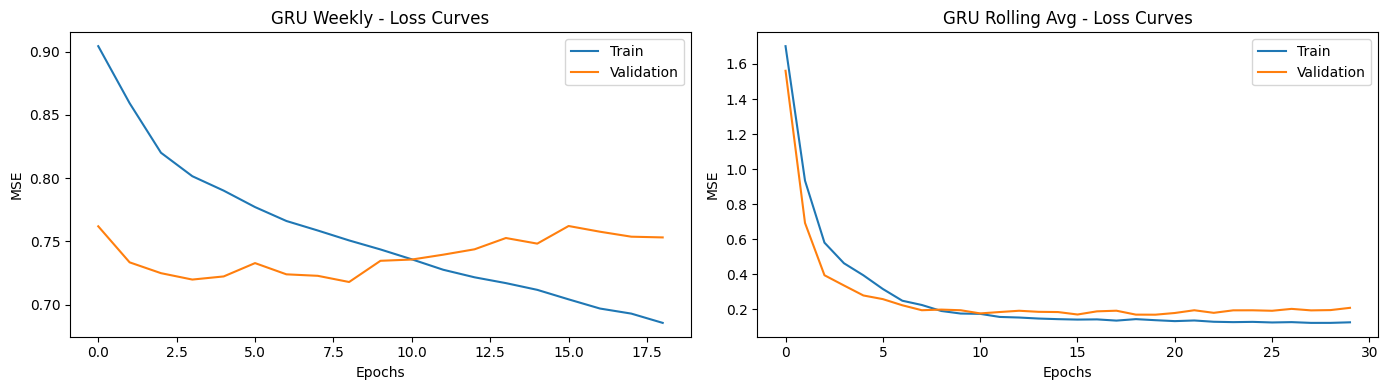

In [37]:
# GRU Training Loss Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_gru_w.history['loss'], label='Train')
axes[0].plot(history_gru_w.history['val_loss'], label='Validation')
axes[0].set_title('GRU Weekly - Loss Curves')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history_gru_r.history['loss'], label='Train')
axes[1].plot(history_gru_r.history['val_loss'], label='Validation')
axes[1].set_title('GRU Rolling Avg - Loss Curves')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('MSE')
axes[1].legend()

plt.tight_layout()
plt.show()

11/11 [==============================] - 0s 2ms/step


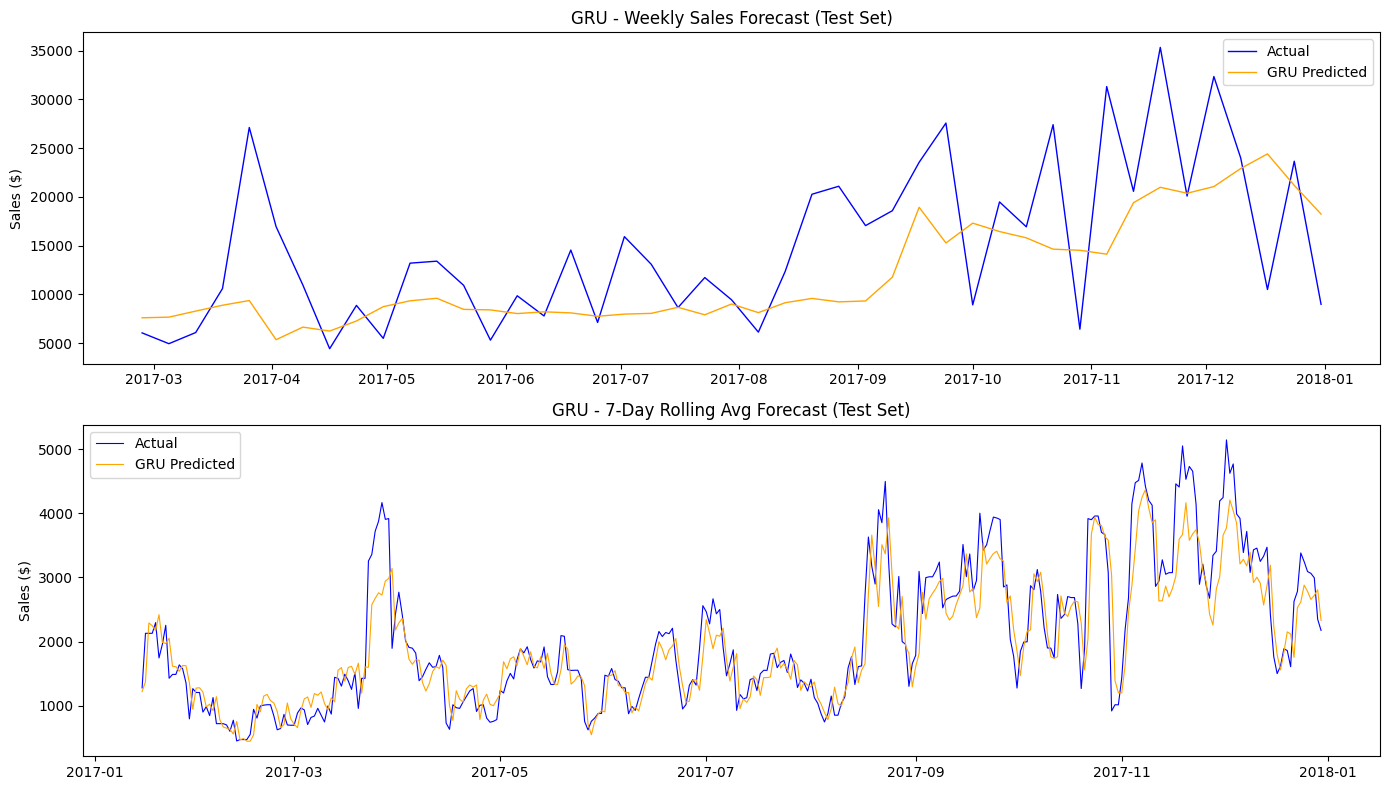

In [38]:
# GRU Predictions Comparison
pred_gru_w = model_gru_w.predict(test_Xw)
pred_gru_r = model_gru_r.predict(test_Xr)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Weekly
pred_gw_inv = scaler_w_out.inverse_transform(pred_gru_w).flatten()
axes[0].plot(test_dates_w, actual_w, label="Actual", color='blue', linewidth=1)
axes[0].plot(test_dates_w, pred_gw_inv, label="GRU Predicted", color='orange', linewidth=1)
axes[0].set_title('GRU - Weekly Sales Forecast (Test Set)')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()

# Rolling
pred_gr_inv = scaler_r_out.inverse_transform(pred_gru_r).flatten()
axes[1].plot(test_dates_r, actual_r, label="Actual", color='blue', linewidth=0.8)
axes[1].plot(test_dates_r, pred_gr_inv, label="GRU Predicted", color='orange', linewidth=0.8)
axes[1].set_title('GRU - 7-Day Rolling Avg Forecast (Test Set)')
axes[1].set_ylabel('Sales ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Results Comparison & Visualization

**What:** We compute MSE, RMSE, and MAE metrics for all 4 model variants (LSTM/GRU × Weekly/Rolling) on the held-out test set, and visualize the results with bar charts.

**Why:** Quantitative metrics on unseen test data provide an objective measure of model performance. Comparing across both architectures and data granularities reveals which combination best captures the underlying sales patterns. RMSE penalizes large errors more heavily (useful for business planning), while MAE gives an intuitive "average dollar error" interpretation.

In [39]:
# Quantitative Comparison — All Models
from sklearn.metrics import mean_squared_error, mean_absolute_error

results = {}

# Weekly models
results['LSTM Weekly'] = {
    'MSE': mean_squared_error(actual_w, pred_w_inv),
    'MAE': mean_absolute_error(actual_w, pred_w_inv),
}
results['GRU Weekly'] = {
    'MSE': mean_squared_error(actual_w, pred_gw_inv),
    'MAE': mean_absolute_error(actual_w, pred_gw_inv),
}

# Rolling models
results['LSTM Rolling'] = {
    'MSE': mean_squared_error(actual_r, pred_r_inv),
    'MAE': mean_absolute_error(actual_r, pred_r_inv),
}
results['GRU Rolling'] = {
    'MSE': mean_squared_error(actual_r, pred_gr_inv),
    'MAE': mean_absolute_error(actual_r, pred_gr_inv),
}

print("=" * 65)
print("Model Performance Comparison (Test Set)")
print("=" * 65)
print(f"{'Model':<20} {'MSE':>15} {'RMSE':>15} {'MAE':>15}")
print("-" * 65)
for name, metrics in results.items():
    rmse = np.sqrt(metrics['MSE'])
    print(f"{name:<20} {metrics['MSE']:>15,.2f} {rmse:>15,.2f} {metrics['MAE']:>15,.2f}")
print("=" * 65)

best_model = min(results.items(), key=lambda x: x[1]['MSE'])
print(f"\nBest model (lowest MSE): {best_model[0]}")

Model Performance Comparison (Test Set)
Model                            MSE            RMSE             MAE
-----------------------------------------------------------------
LSTM Weekly            69,143,866.12        8,315.28        6,125.52
GRU Weekly             54,954,820.73        7,413.15        5,602.83
LSTM Rolling              231,602.79          481.25          341.76
GRU Rolling               231,283.42          480.92          340.83

Best model (lowest MSE): GRU Rolling


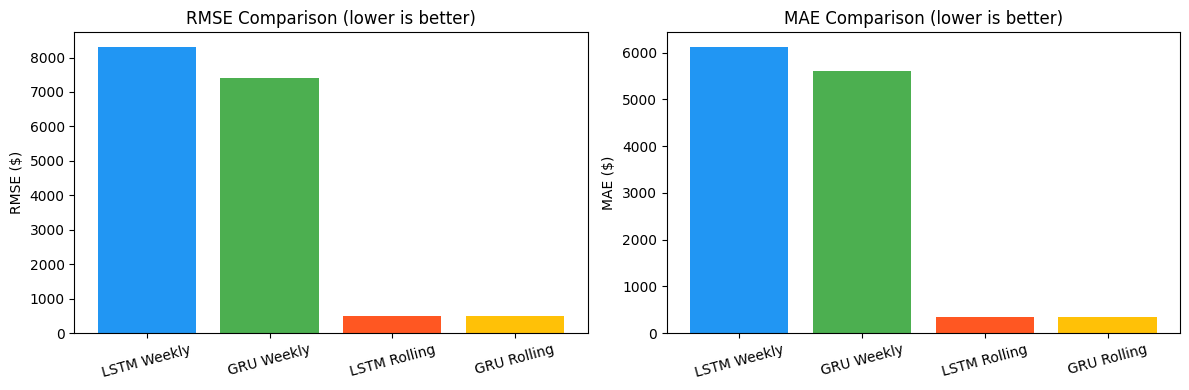

In [40]:
# Visual bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

model_names = list(results.keys())
mse_vals = [results[m]['MSE'] for m in model_names]
mae_vals = [results[m]['MAE'] for m in model_names]

colors = ['#2196F3', '#4CAF50', '#FF5722', '#FFC107']

axes[0].bar(model_names, [np.sqrt(m) for m in mse_vals], color=colors)
axes[0].set_title('RMSE Comparison (lower is better)')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(model_names, mae_vals, color=colors)
axes[1].set_title('MAE Comparison (lower is better)')
axes[1].set_ylabel('MAE ($)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Summary

This analysis covered all required data science components:

1. **EDA** — Distribution, trends, day-of-week patterns using pandas + matplotlib
2. **Feature Extraction** — Cyclical sine/cosine encoding (day-of-week, day-of-year for daily; week-of-year, month for weekly)
3. **Scaling** — StandardScaler applied separately to inputs and target variable
4. **Train/Validation/Test Split** — Time-based: 2014-2015 / 2016 / 2017
5. **LSTM Model** — Keras Sequential LSTM(16) + Dense(1) with EarlyStopping, trained on both weekly and rolling avg data
6. **GRU Model** — Same architecture with GRU layer, also trained on both granularities
7. **Visualization** — Loss curves, actual vs predicted plots, quantitative metrics (MSE, RMSE, MAE)

**Key findings:** The rolling average representation consistently outperforms weekly aggregation (by orders of magnitude in MSE), indicating that retaining daily-level granularity with smoothing is superior to coarse weekly aggregation for this dataset. Between architectures, LSTM and GRU perform comparably on the rolling data, suggesting that for this relatively simple forecasting task, the additional complexity of LSTM gates provides no significant advantage over GRU.